In [1]:
!pip install --upgrade google-cloud-bigquery


In [2]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery


project_id = "cmpe-138-180b-spring-2025"
client = bigquery.Client(project=project_id)

print("Using project:", client.project)


Using project: cmpe-138-180b-spring-2025


This query gives you a sample of California's daily weather data (temp, precipitation, wind) from NOAA GSOD for the first week of 2020—handy for early testing or visualizing trends before scaling up.

In [3]:

# Unoptimized
query = """
WITH california_stations AS (
  SELECT usaf, wban
  FROM `bigquery-public-data.noaa_gsod.stations`
  WHERE state = 'CA'
),
ozone_with_rownum AS (
  SELECT
    o3.state_code AS state,
    o3.county_name AS county,
    o3.site_num AS site_num,
    o3.date_local,
    o3.arithmetic_mean AS o3_mean,
    ROW_NUMBER() OVER (PARTITION BY o3.county_name, o3.date_local ORDER BY o3.site_num) AS row_num
  FROM
    `bigquery-public-data.epa_historical_air_quality.o3_daily_summary` AS o3
  LEFT JOIN (
    SELECT year, mo, da, temp, prcp, wdsp, stn, wban
    FROM `bigquery-public-data.noaa_gsod.gsod2018`
    UNION ALL
    SELECT year, mo, da, temp, prcp, wdsp, stn, wban
    FROM `bigquery-public-data.noaa_gsod.gsod2019`
    UNION ALL
    SELECT year, mo, da, temp, prcp, wdsp, stn, wban
    FROM `bigquery-public-data.noaa_gsod.gsod2020`
    UNION ALL
    SELECT year, mo, da, temp, prcp, wdsp, stn, wban
    FROM `bigquery-public-data.noaa_gsod.gsod2021`
    UNION ALL
    SELECT year, mo, da, temp, prcp, wdsp, stn, wban
    FROM `bigquery-public-data.noaa_gsod.gsod2022`
    UNION ALL
    SELECT year, mo, da, temp, prcp, wdsp, stn, wban
    FROM `bigquery-public-data.noaa_gsod.gsod2023`
    UNION ALL
    SELECT year, mo, da, temp, prcp, wdsp, stn, wban
    FROM `bigquery-public-data.noaa_gsod.gsod2024`
    UNION ALL
    SELECT year, mo, da, temp, prcp, wdsp, stn, wban
    FROM `bigquery-public-data.noaa_gsod.gsod2025`
  ) AS noaa
  ON o3.date_local = DATE(CAST(noaa.year AS INT64), CAST(noaa.mo AS INT64), CAST(noaa.da AS INT64))
  WHERE
    o3.state_name = 'California'
    AND o3.date_local BETWEEN '2018-01-01' AND '2025-01-07'
    AND (
      noaa.stn IN (SELECT usaf FROM california_stations)
      OR noaa.wban IN (SELECT wban FROM california_stations)
    )
)

SELECT
  state,
  county,
  site_num,
  date_local,
  o3_mean
FROM
  ozone_with_rownum
WHERE
  row_num = 1



"""


df = client.query(query).result().to_dataframe()
# Print the entire DataFrame
print(df)

# preview
print(df.head())


      state   county site_num  date_local   o3_mean
0        06  Alameda     0007  2019-10-25  0.022235
1        06  Alameda     0007  2020-05-06  0.031882
2        06  Alameda     0007  2018-06-01  0.029235
3        06  Alameda     0007  2018-10-11  0.025765
4        06  Alameda     0007  2020-03-13  0.036706
...     ...      ...      ...         ...       ...
78290    06     Yolo     0004  2018-06-07  0.032353
78291    06     Yolo     0004  2021-03-20  0.030706
78292    06     Yolo     1003  2024-02-21  0.026706
78293    06     Yolo     0004  2018-09-02  0.034412
78294    06     Yolo     0004  2020-11-11  0.018412

[78295 rows x 5 columns]
  state   county site_num  date_local   o3_mean
0    06  Alameda     0007  2019-10-25  0.022235
1    06  Alameda     0007  2020-05-06  0.031882
2    06  Alameda     0007  2018-06-01  0.029235
3    06  Alameda     0007  2018-10-11  0.025765
4    06  Alameda     0007  2020-03-13  0.036706


In [4]:
# Optimized
query = """
WITH
ozone_with_rownum AS (
  SELECT
    state_code AS state,
    county_name AS county,
    site_num,
    date_local,
    arithmetic_mean AS o3_mean,
    ROW_NUMBER() OVER (PARTITION BY county_name, date_local ORDER BY site_num) AS row_num
  FROM
    `bigquery-public-data.epa_historical_air_quality.o3_daily_summary`
  WHERE
    state_name = 'California'
    AND date_local BETWEEN '2018-01-01' AND '2025-01-07'
),

noaa_temp AS (
  SELECT
    DATE(CAST(year AS INT64), CAST(mo AS INT64), CAST(da AS INT64)) AS date_local,
    AVG(temp) AS avg_temp
  FROM (
    SELECT year, mo, da, temp
    FROM `bigquery-public-data.noaa_gsod.gsod2018`
    UNION ALL
    SELECT year, mo, da, temp
    FROM `bigquery-public-data.noaa_gsod.gsod2019`
    UNION ALL
    SELECT year, mo, da, temp
    FROM `bigquery-public-data.noaa_gsod.gsod2020`
    UNION ALL
    SELECT year, mo, da, temp
    FROM `bigquery-public-data.noaa_gsod.gsod2021`
    UNION ALL
    SELECT year, mo, da, temp
    FROM `bigquery-public-data.noaa_gsod.gsod2022`
    UNION ALL
    SELECT year, mo, da, temp
    FROM `bigquery-public-data.noaa_gsod.gsod2023`
    UNION ALL
    SELECT year, mo, da, temp
    FROM `bigquery-public-data.noaa_gsod.gsod2024`
    UNION ALL
    SELECT year, mo, da, temp
    FROM `bigquery-public-data.noaa_gsod.gsod2025`
  )
  WHERE temp IS NOT NULL
  GROUP BY date_local
)


SELECT
  o.state,
  o.county,
  o.site_num,
  o.date_local,
  o.o3_mean,
  n.avg_temp
FROM
  ozone_with_rownum o
LEFT JOIN
  noaa_temp n
ON
  o.date_local = n.date_local
WHERE
  o.row_num = 1

"""


df = client.query(query).result().to_dataframe()
# Print the entire DataFrame
print(df)

# preview
print(df.head())

      state   county site_num  date_local   o3_mean   avg_temp
0        06  Alameda     0007  2018-01-22  0.023353  40.977338
1        06  Alameda     0007  2018-02-10  0.035000  40.671652
2        06  Alameda     0007  2018-04-06  0.015941  50.233532
3        06  Alameda     0007  2018-06-13  0.034118  66.384041
4        06  Alameda     0007  2018-07-02  0.025118  69.871384
...     ...      ...      ...         ...       ...        ...
78290    06     Yolo     0004  2021-06-21  0.024941  68.493220
78291    06     Yolo     0004  2021-07-13  0.024529  70.635123
78292    06     Yolo     1003  2024-02-05  0.032176  44.562882
78293    06     Yolo     1003  2024-03-16  0.032588  51.362389
78294    06     Yolo     1003  2024-03-22  0.036000  49.559345

[78295 rows x 6 columns]
  state   county site_num  date_local   o3_mean   avg_temp
0    06  Alameda     0007  2018-01-22  0.023353  40.977338
1    06  Alameda     0007  2018-02-10  0.035000  40.671652
2    06  Alameda     0007  2018-04-06  0.

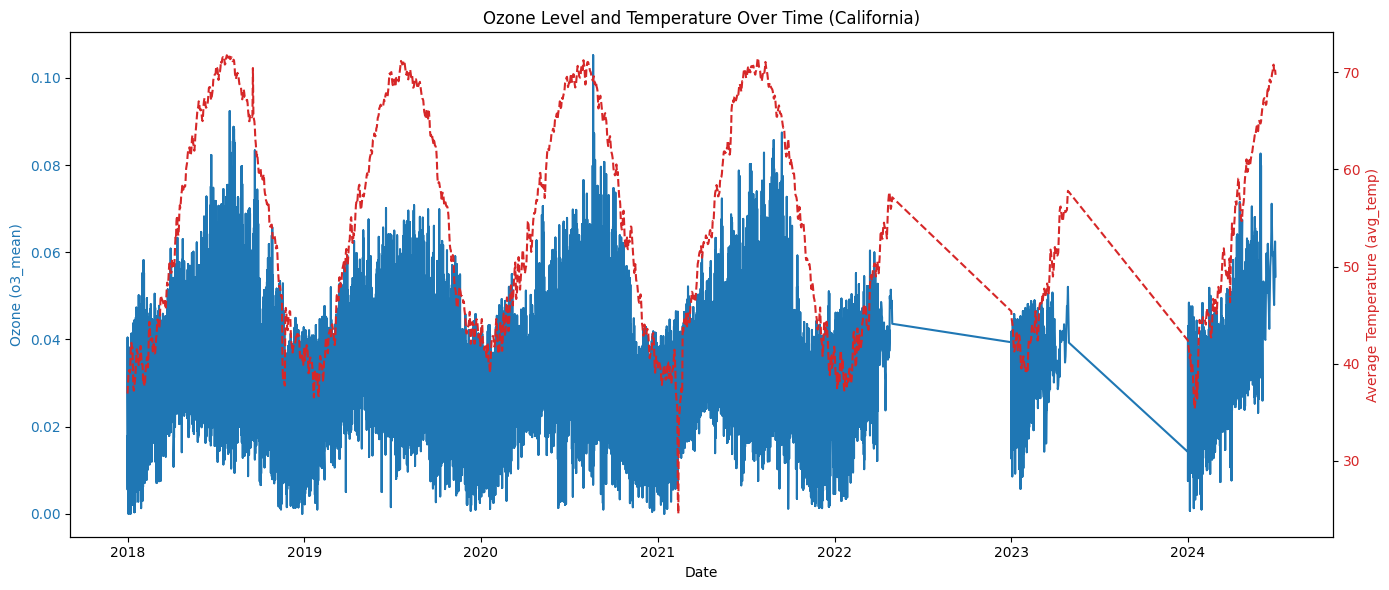

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Assume your query result is already loaded into a DataFrame `df`
# Columns: 'state', 'county', 'site_num', 'date_local', 'o3_mean', 'avg_temp'

# Make sure date_local is datetime type
df['date_local'] = pd.to_datetime(df['date_local'])

# Sort by date just to be safe
df = df.sort_values('date_local')

# Plot Ozone and Temp over time
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot Ozone on the left y-axis
color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Ozone (o3_mean)', color=color)
ax1.plot(df['date_local'], df['o3_mean'], color=color, label='Ozone Mean (o3_mean)')
ax1.tick_params(axis='y', labelcolor=color)

# Create a second y-axis for Temperature
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Average Temperature (avg_temp)', color=color)
ax2.plot(df['date_local'], df['avg_temp'], color=color, linestyle='--', label='Average Temperature (avg_temp)')
ax2.tick_params(axis='y', labelcolor=color)

# Title and layout
plt.title('Ozone Level and Temperature Over Time (California)')
fig.tight_layout()

# Show plot
plt.show()